In [1]:
import pandas as pd
import data_profiling
import numpy as np
from data_profiling import ProfileReport

In [2]:
df = pd.read_csv('../data/train.csv')

In [4]:
profile = ProfileReport(df, title="Profiling Report", explorative=True)
profile.to_file('report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:11<00:00,  1.28it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
df.shape

(690088, 15)

In [4]:
df.dtypes

id                           int64
health_condition            object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

In [5]:
df.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [6]:
df.head(10)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
5,5,at-risk,5.11,82.8,24.43,2290.0,2134.0,29.2,2.02,veg,low,poor,sedentary,occasional,male
6,6,at-risk,8.21,71.1,24.14,2723.0,12984.0,54.5,2.01,balanced,low,NaN,moderate,no,female
7,7,at-risk,7.47,87.0,23.51,NaN,3096.0,37.5,0.51,balanced,low,average,sedentary,occasional,male
8,8,unhealthy,5.94,75.4,24.36,NaN,12165.0,61.6,1.56,veg,high,average,active,no,other
9,9,at-risk,6.97,80.1,20.47,2928.0,13108.0,51.9,2.53,veg,medium,good,active,no,male


In [7]:
missing = df.isnull().mean()*100
print(missing[missing>0].sort_values(ascending=False))

stress_level               12.000064
sleep_duration             11.012943
sleep_quality               8.452690
calorie_expenditure         7.658878
water_intake                6.300211
physical_activity_level     5.306715
smoking_alcohol             4.141791
gender                      3.097141
step_count                  2.016554
bmi                         2.013946
heart_rate                  1.135073
diet_type                   1.000017
exercise_duration           1.000017
dtype: float64


In [8]:
n_dupes = df.duplicated().sum()
n_dupes

np.int64(0)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['health_condition'] = le.fit_transform(df['health_condition'])

In [10]:
print(le.classes_)

['at-risk' 'fit' 'unhealthy']


In [11]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [12]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df = numeric_df.drop(columns=['id'])

corr_matrix = numeric_df.corr()

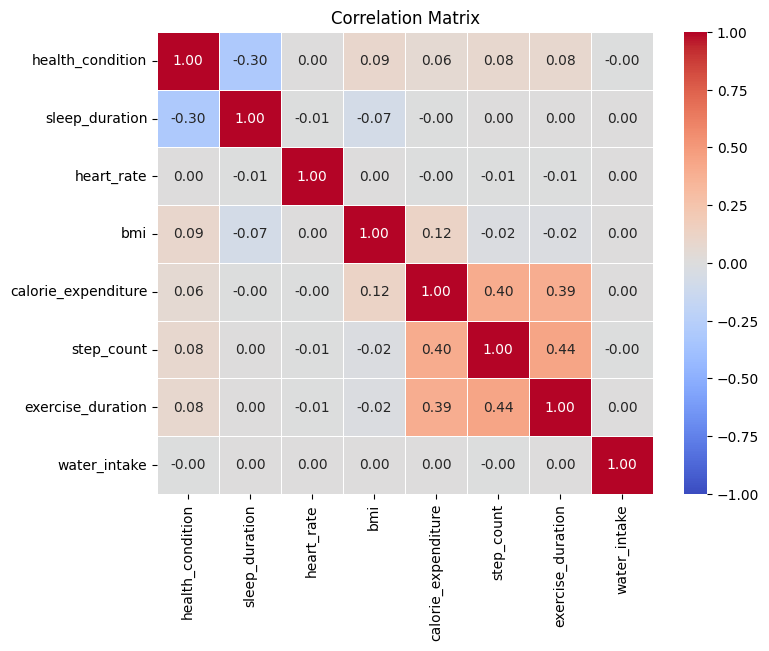

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidth=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix')
plt.show()

In [14]:
df.dtypes

id                           int64
health_condition             int64
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

In [15]:
df['diet_type'].isnull().sum()

np.int64(6901)

In [16]:
df['diet_type'].value_counts()

diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64

In [17]:
df.dropna(subset=['diet_type'], inplace=True)

In [18]:
df['diet_type'].isnull().sum()

np.int64(0)

In [19]:
df = pd.get_dummies(df, columns=['diet_type'], drop_first=True, dtype=int)

In [20]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,diet_type_non-veg,diet_type_veg
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,high,average,sedentary,yes,female,0,1
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,low,average,moderate,yes,other,1,0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,high,poor,active,yes,male,0,1
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,high,average,active,occasional,female,0,1
4,4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,NaN,average,sedentary,NaN,male,0,1


In [21]:
df['stress_level'].value_counts()

stress_level
medium    259141
high      175982
low       166022
Name: count, dtype: int64

In [22]:
df['stress_level'].isnull().sum()

np.int64(82042)

In [23]:
df['stress_level'] = df.groupby('health_condition')['stress_level'].transform(
    lambda x: x.fillna(x.mode()[0])
)

In [24]:
df['stress_level'].isnull().sum()

np.int64(0)

In [25]:
stress_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['stress_level'] = df['stress_level'].map(stress_mapping)

In [26]:
df['stress_level'].value_counts()

stress_level
1    329590
2    182846
0    170751
Name: count, dtype: int64

In [27]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,diet_type_non-veg,diet_type_veg
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,2,average,sedentary,yes,female,0,1
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0,average,moderate,yes,other,1,0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,2,poor,active,yes,male,0,1
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,2,average,active,occasional,female,0,1
4,4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,1,average,sedentary,NaN,male,0,1


In [29]:
df.dtypes

id                           int64
health_condition             int64
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
stress_level                 int64
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
diet_type_non-veg            int64
diet_type_veg                int64
dtype: object

In [30]:
df['sleep_quality'].isnull().sum()

np.int64(57733)

In [31]:
df['sleep_quality'].value_counts()

sleep_quality
average    211823
poor       210020
good       203611
Name: count, dtype: int64

In [35]:
df['sleep_quality'] = df.groupby('stress_level')['sleep_quality'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'average')
)

In [ ]:
sleep_mapping = {}